In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import confusion_matrix, classification_report, f1_score
from sklearn.model_selection import train_test_split

In [2]:
# split from preprocessed data

df = pd.read_csv('../data/preprocessed_result_260305_02.csv')
X = df['tweet']
y = df['label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Vectorize the text data using TF-IDF
vectorizer = TfidfVectorizer(max_features=5000)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

Fitting 3 folds for each of 27 candidates, totalling 81 fits
Best parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 300}

Best Random Forest Classification Report:
              precision    recall  f1-score   support

   Non-Toxic       0.96      0.95      0.95      5256
       Toxic       0.95      0.96      0.96      5302

    accuracy                           0.96     10558
   macro avg       0.96      0.96      0.96     10558
weighted avg       0.96      0.96      0.96     10558



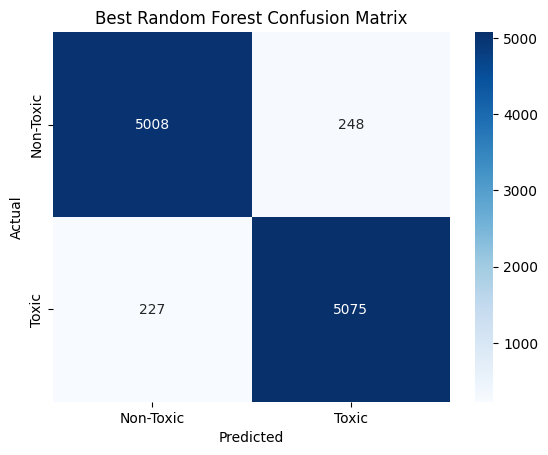

In [3]:
# hyperparameter tuning for best model (Random Forest)
from sklearn.model_selection import GridSearchCV
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}
grid_search = GridSearchCV(estimator=RandomForestClassifier(random_state=42), param_grid=param_grid, cv=3, n_jobs=-1, verbose=2)
grid_search.fit(X_train_tfidf, y_train)
print(f"Best parameters: {grid_search.best_params_}")
best_rf = grid_search.best_estimator_
y_pred_rf = best_rf.predict(X_test_tfidf)
print("\nBest Random Forest Classification Report:")
print(classification_report(y_test, y_pred_rf, target_names=['Non-Toxic', 'Toxic']))
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', xticklabels=['Non-Toxic', 'Toxic'], yticklabels=['Non-Toxic', 'Toxic'])
plt.title('Best Random Forest Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()